## module 2 — subject localizer (YOLO, zero-shot)

Draws a bounding box around the plant/flower subject in a photo using a **pretrained,
open-vocabulary YOLO (YOLO-World)** — this is the `subject-localizer` row from
`models/planned.json` (module `identify`, task `detection/segmentation`).

**Why zero-shot, not fine-tuned:** the dataset has whole-image species labels only, no
bounding-box annotations, so there's nothing to fine-tune a detector on here. Instead this
prompts YOLO-World with plant-related class names (`"flower"`, `"plant"`, `"leaf"`, ...) to
localize the subject without any plant-specific training.

**What's reported, and what isn't:** with no ground-truth boxes there's no IoU/mAP to
compute against — that's why the planned metric list also has `Δtop-1`: does cropping to
the localized subject before feeding a trained classifier change its accuracy? That's the
number this notebook actually measures, on a small streamed sample. (A future pass could
hand-label a small validation subset with real boxes and report IoU/mAP properly.)

Runs locally or on Colab (auto-detected, same bootstrap as 03–05). Read-only: it doesn't
train or publish anything.


In [1]:
# get bvtrain (shared plumbing) + ultralytics: locally it's ../bvtrain; on colab/kaggle we clone the repo
import os, sys
_CANDS = ["..", ".", "botanical-vision"]
if not any(os.path.isdir(f"{p}/bvtrain") for p in _CANDS):
    os.system("git clone -q https://github.com/babnigg/botanical-vision.git")
for _p in _CANDS:
    if os.path.isdir(f"{_p}/bvtrain"):
        sys.path.insert(0, _p)
        break

# try:
#     import ultralytics
# except ImportError:
#     os.system("pip install -q ultralytics")

import matplotlib.patches as patches
import matplotlib.pyplot as plt
from ultralytics import YOLO

import bvtrain as bv
from share import hub
from share.model import build_predictor

import pandas as pd
import numpy as np

In [2]:
env = bv.setup()


device: cpu | data: huggingface | env: local


In [3]:
# YOLO-World: open-vocabulary detection - prompt it with the classes we care about instead
# of fine-tuning on boxes we don't have. Falls back to stock yolov8n (COCO's "potted plant")
# if the -world weights can't be fetched (e.g. a locked-down runner with no internet).
SUBJECT_CLASSES = ["flower", "flowering plant", "potted plant", "leaf", "branch with flowers"]
try:
    yolo = YOLO("yolov8s-world.pt")
    yolo.set_classes(SUBJECT_CLASSES)
except Exception as e:
    print(f"YOLO-World unavailable ({e}); falling back to stock yolov8n (COCO classes only)")
    yolo = YOLO("yolov8n.pt")
    SUBJECT_CLASSES = None  # stock COCO class names apply instead


In [4]:
# a small streamed sample from the same test split share.score uses - no full download.
# shuffled: the raw stream is grouped by species, so an unshuffled .take() grabs N copies
# of one species instead of a diverse sample.
N_SAMPLES = 300
CONF_THRESH = 0.1
PAD_GRID = [0.0, 0.1, 0.2, 0.3]
from datasets import load_dataset

stream = load_dataset(env.hf_repo, split="test", streaming=True).shuffle(seed=42, buffer_size=2000)
samples = []
for ex in stream:
    samples.append((ex["image"].convert("RGB"), ex["species"]))
    if len(samples) >= N_SAMPLES:
        break
print(f"{len(samples)} sample images | {len(set(sp for _, sp in samples))} distinct species")

def greenness(img):
    a = np.asarray(img.resize((64, 64)), dtype=np.int16)
    r, g, b = a[..., 0], a[..., 1], a[..., 2]
    return float(np.mean((g > r) & (g > b)))

meta = [{"greenness": greenness(img), "min_side": min(img.size)} for img, _ in samples]


c:\Users\swtak\Documents\Computer Vision\Final Project\botanical-vision\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


300 sample images | 125 distinct species


In [5]:
def pick_subject_box(result):
    """Highest-confidence box as the subject; full-image fallback if nothing fires."""
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        h, w = result.orig_shape
        return (0, 0, w, h), 0.0, 0
    best = int(boxes.conf.argmax())
    x1, y1, x2, y2 = boxes.xyxy[best].tolist()
    return (x1, y1, x2, y2), float(boxes.conf[best]), len(boxes)


# default conf=0.25 misses most macro flower photos (YOLO-World's classes are tuned to
# everyday COCO/LVIS-style objects, not close-up botanical shots) - a lower threshold
# trades some noise for a much higher hit rate; the full-image fallback stays safe either way.
CONF_THRESH = 0.1
results = yolo.predict([img for img, _ in samples], conf=CONF_THRESH, verbose=False)
boxes = [pick_subject_box(r) for r in results]
# for (img, sp), (box, conf) in zip(samples, boxes):
#     print(f"{sp:<30} conf={conf:.2f} box={tuple(round(v) for v in box)}")


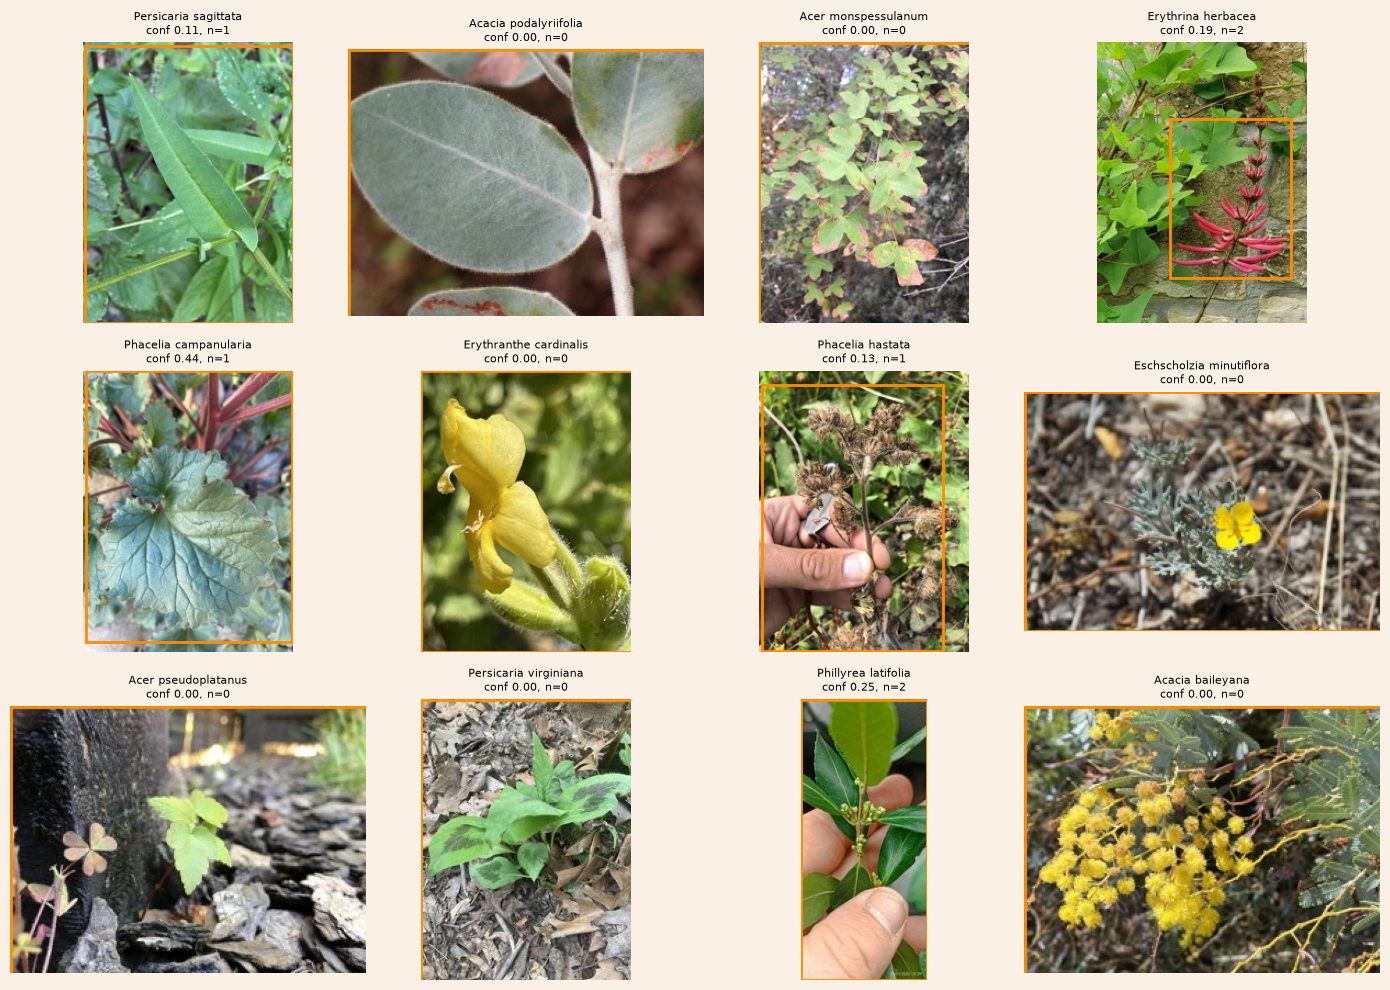

In [6]:
n_show = 12  # how many to visualize, independent of N_SAMPLES
rng = np.random.default_rng(0)
show_idx = rng.choice(len(samples), size=min(n_show, len(samples)), replace=False)

fig, axs = plt.subplots(3, 4, figsize=(14, 10))
fig.set_facecolor("linen")
for ax, i in zip(axs.ravel(), show_idx):
    img, sp = samples[i]
    box, conf, n_boxes = boxes[i]
    ax.imshow(img)
    x1, y1, x2, y2 = box
    ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                    fill=False, edgecolor="darkorange", linewidth=2))
    ax.set_title(f"{sp}\nconf {conf:.2f}, n={n_boxes}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

### does localizing help the classifier? (Δtop-1)

Crop each sample to its padded subject box, then compare top-1 on the full image vs. the
crop using the team's best classifier. Uses a local checkpoint if you have one
(`04_train_improved`'s output), otherwise pulls the current leaderboard champion from the
shared Hugging Face model repo — same source `share.leaderboard` reads.


In [8]:
CKPT_DIR = bv.checkpoint_dir(env)
local_ckpt = f"{CKPT_DIR}/resnet50_improved_best.pt"
if os.path.exists(local_ckpt):
    bundle_path = local_ckpt
    print(f"using local checkpoint: {bundle_path}")
else:
    shared = sorted(hub.list_models(), key=lambda m: m.get("val_acc") or 0, reverse=True)
    if not shared:
        raise SystemExit("no local checkpoint and nothing shared yet - train + publish first")
    champ = shared[0]
    bundle_path = hub.pull(champ["author"], champ["name"])
    print(f"using shared model: {champ['author']}/{champ['name']} (val_acc {champ.get('val_acc')})")

predict_topk = build_predictor(bundle_path)

using shared model: dbabnigg/resnet50_baseline_babnigg (val_acc 0.5881901840490797)


In [9]:
def pad_box(box, w, h, pad):
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    x1 = max(0, x1 - bw * pad); y1 = max(0, y1 - bh * pad)
    x2 = min(w, x2 + bw * pad); y2 = min(h, y2 + bh * pad)
    return x1, y1, x2, y2

rows = []
for (img, sp), (box, conf, n_boxes), m in zip(samples, boxes, meta):
    w, h = img.size
    row = {
        "species": sp, "yolo_conf": conf, "n_boxes": n_boxes,
        "greenness": m["greenness"], "min_side": m["min_side"],
        "full_correct": int(predict_topk(img)[0] == sp),
    }
    for pad in PAD_GRID:
        crop = img.crop(pad_box(box, w, h, pad)) if conf > 0 else img
        row[f"crop_correct_pad{pad}"] = int(predict_topk(crop)[0] == sp)
    rows.append(row)

log = pd.DataFrame(rows)

full_top1 = log["full_correct"].mean()
print(f"n={len(log)}  full-image top-1={full_top1:.3f}")
for pad in PAD_GRID:
    col = f"crop_correct_pad{pad}"
    print(f"pad={pad:<4} cropped top-1={log[col].mean():.3f}  delta={log[col].mean() - full_top1:+.3f}")

n=300  full-image top-1=0.463
pad=0.0  cropped top-1=0.400  delta=-0.063
pad=0.1  cropped top-1=0.410  delta=-0.053
pad=0.2  cropped top-1=0.417  delta=-0.047
pad=0.3  cropped top-1=0.423  delta=-0.040


best pad on this run: 0.3


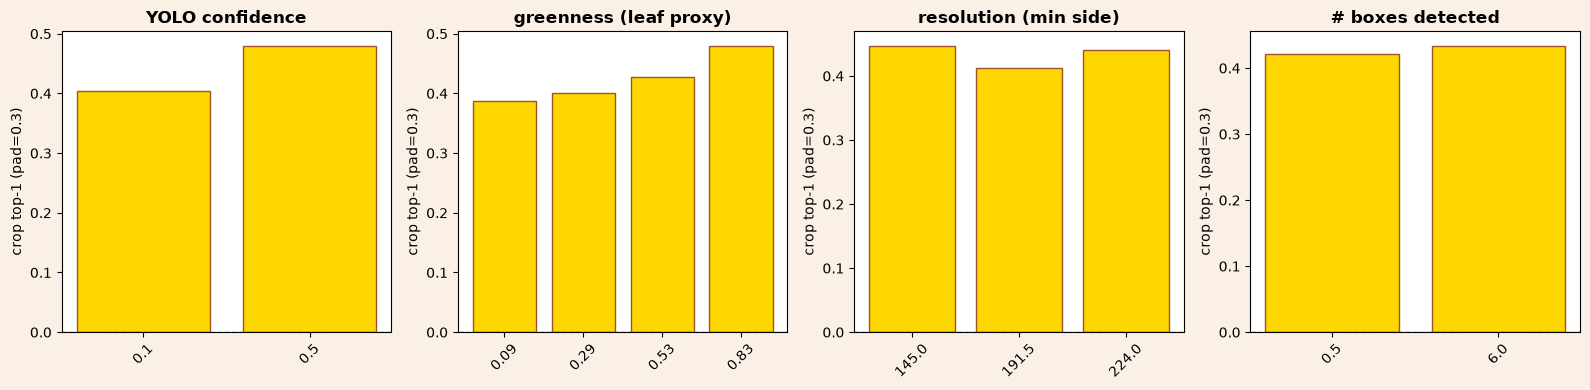

In [10]:
def acc_by_bin(values, correct, q=5):
    df = pd.DataFrame({"v": values, "c": correct})
    df["bin"] = pd.qcut(df["v"], q, duplicates="drop")
    g = df.groupby("bin", observed=True)["c"].mean()
    return [str(round(iv.mid, 2)) for iv in g.index], g.values

best_pad = max(PAD_GRID, key=lambda p: log[f"crop_correct_pad{p}"].mean())
delta_col = f"crop_correct_pad{best_pad}"
log["delta"] = log[delta_col] - log["full_correct"]
print(f"best pad on this run: {best_pad}")

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
fig.set_facecolor("linen")
for ax, (name, vals) in zip(axs, [("YOLO confidence", log["yolo_conf"]),
                                    ("greenness (leaf proxy)", log["greenness"]),
                                    ("resolution (min side)", log["min_side"]),
                                    ("# boxes detected", log["n_boxes"])]):
    xs, ys = acc_by_bin(vals, log[delta_col], q=4) if vals.nunique() > 4 else (vals.astype(str), log.groupby(vals)[delta_col].mean())
    ax.bar(xs, ys, color="gold", edgecolor="sienna")
    ax.axhline(0, ls="--", color="sienna", lw=1)
    ax.set_title(name, weight="bold"); ax.set_ylabel(f"crop top-1 (pad={best_pad})")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### can ensembling beat hard-cropping?

The delta chart above breaks down *where* cropping hurts, but the padding sweep in the
Δtop-1 cell already shows it hurts everywhere, at every pad tested. Before concluding
localization doesn't help at all, try a softer combination: instead of replacing the
full image with the crop, average the classifier's softmax over *both* and see if that
recovers what hard-cropping throws away. `predict_topk` only exposes the top-k label
names, so this rebuilds a thin probs-returning predictor from the same bundle (same
architecture/weights/transform as `share.model.build_predictor`) rather than editing
shared code just for this.

In [11]:
import torch
from torch import nn
from torchvision import transforms, models as tv_models
from share.model import load_bundle
from share.constants import IMG_SIZE, MEAN, STD

b = load_bundle(bundle_path)
ens_labels = b["labels"]
net = tv_models.resnet50()
net.fc = nn.Linear(net.fc.in_features, len(ens_labels))
net.load_state_dict(b["state_dict"])
net.eval()
tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(b.get("img_size", IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(b.get("mean", MEAN), b.get("std", STD)),
])

def predict_probs(img):
    x = tf(img.convert("RGB")).unsqueeze(0)
    with torch.no_grad():
        return net(x).float().softmax(1)[0]

ens_rows = []
for (img, sp), (box, conf, n_boxes) in zip(samples, boxes):
    w, h = img.size
    full_probs = predict_probs(img)
    row = {
        "species": sp, "yolo_conf": conf, "n_boxes": n_boxes,
        "full_correct": int(ens_labels[int(full_probs.argmax())] == sp),
    }
    for pad in PAD_GRID:
        crop = img.crop(pad_box(box, w, h, pad)) if conf > 0 else img
        crop_probs = predict_probs(crop)
        row[f"crop_correct_pad{pad}"] = int(ens_labels[int(crop_probs.argmax())] == sp)
        ens_probs = (full_probs + crop_probs) / 2
        row[f"ens_correct_pad{pad}"] = int(ens_labels[int(ens_probs.argmax())] == sp)
    ens_rows.append(row)

ens_log = pd.DataFrame(ens_rows)
ens_full_top1 = ens_log["full_correct"].mean()
print(f"n={len(ens_log)}  full-image top-1={ens_full_top1:.3f}\n")
print(f"{'pad':<6}{'crop-only':<12}{'ensemble':<12}{'crop delta':<12}{'ensemble delta':<12}")
for pad in PAD_GRID:
    crop_acc = ens_log[f"crop_correct_pad{pad}"].mean()
    ens_acc = ens_log[f"ens_correct_pad{pad}"].mean()
    print(f"{pad:<6}{crop_acc:<12.3f}{ens_acc:<12.3f}{crop_acc - ens_full_top1:<+12.3f}{ens_acc - ens_full_top1:<+12.3f}")

n=300  full-image top-1=0.463

pad   crop-only   ensemble    crop delta  ensemble delta
0.0   0.400       0.460       -0.063      -0.003      
0.1   0.410       0.447       -0.053      -0.017      
0.2   0.417       0.450       -0.047      -0.013      
0.3   0.423       0.457       -0.040      -0.007      


### does gating on YOLO confidence help?

Ensembling should recover more of the loss when YOLO's box is trustworthy. Check
whether restricting to high-confidence detections closes the remaining gap to the
full-image baseline — and how much of the sample even gets a real detection at
`conf=0.1` versus falling back to the full-image box.

In [12]:
hi_thresholds = [0.0, 0.3, 0.5]
print(f"{'conf >':<8}{'n':<6}{'full':<8}{'crop(pad0)':<12}{'ensemble(pad0)':<14}")
for t in hi_thresholds:
    sub = ens_log[ens_log["yolo_conf"] > t]
    print(f"{t:<8}{len(sub):<6}{sub['full_correct'].mean():<8.3f}"
          f"{sub['crop_correct_pad0.0'].mean():<12.3f}{sub['ens_correct_pad0.0'].mean():<14.3f}")

n_detected = int((ens_log["yolo_conf"] > 0).sum())
print(f"\n{n_detected}/{len(ens_log)} images got a real YOLO detection above conf={CONF_THRESH}; "
      f"the rest fell back to the full-image box (crop == full for those by construction).")

conf >  n     full    crop(pad0)  ensemble(pad0)
0.0     111   0.586   0.414       0.577         
0.3     48    0.604   0.417       0.583         
0.5     20    0.600   0.400       0.550         

111/300 images got a real YOLO detection above conf=0.1; the rest fell back to the full-image box (crop == full for those by construction).


### diagnostics — why does cropping hurt?

Padding, ensembling, and confidence-gating all point the same direction, so look
directly at what's going wrong: pull the cases where the full image was classified
correctly but the pad=0 crop was not, and draw the actual YOLO box. This settles
whether the localizer is boxing the wrong part of the plant (fixable with better
prompting) or a defensible crop that just strips context the classifier relies on
(not fixable by tuning YOLO).

23 of 300 samples: full image right, pad=0 crop wrong


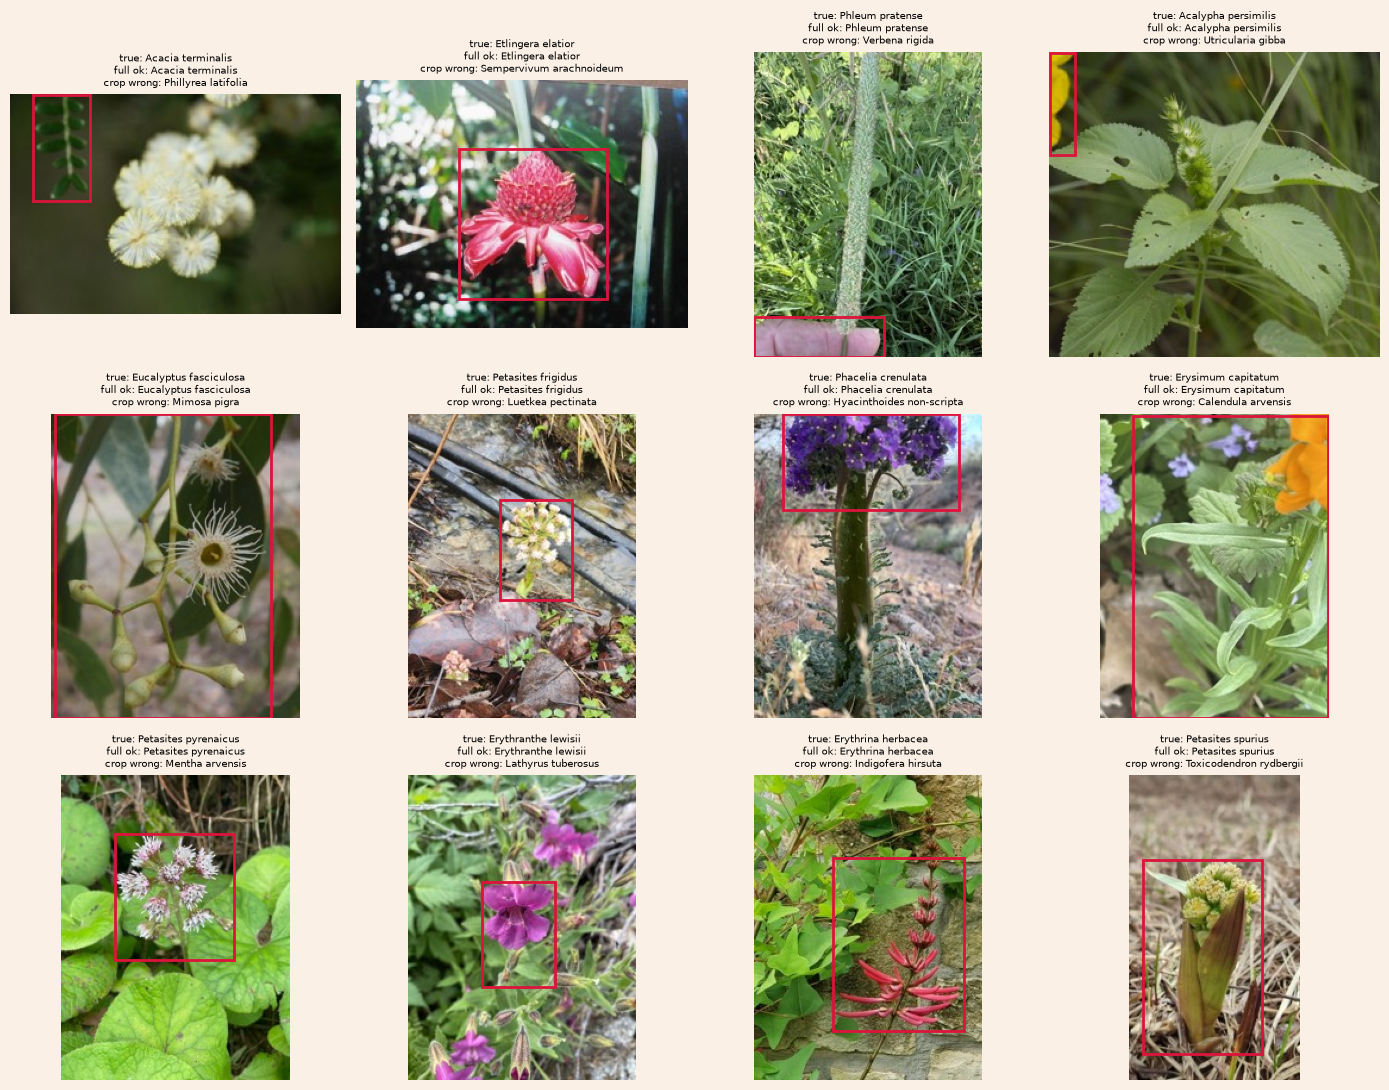

In [13]:
mismatch_idx = ens_log.index[
    (ens_log["full_correct"] == 1) & (ens_log["crop_correct_pad0.0"] == 0)
].tolist()
print(f"{len(mismatch_idx)} of {len(ens_log)} samples: full image right, pad=0 crop wrong")

n_show = min(12, len(mismatch_idx))
show_idx = mismatch_idx[:n_show]

fig, axs = plt.subplots(3, 4, figsize=(14, 11))
fig.set_facecolor("linen")
for ax, i in zip(axs.ravel(), show_idx):
    img, sp = samples[i]
    box, conf, n_boxes = boxes[i]
    w, h = img.size
    crop = img.crop(pad_box(box, w, h, 0.0)) if conf > 0 else img
    full_pred = predict_topk(img)[0]
    crop_pred = predict_topk(crop)[0]
    ax.imshow(img)
    x1, y1, x2, y2 = box
    ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                    fill=False, edgecolor="crimson", linewidth=2))
    ax.set_title(f"true: {sp}\nfull ok: {full_pred}\ncrop wrong: {crop_pred}", fontsize=7)
    ax.axis("off")
for ax in axs.ravel()[n_show:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### what this adds up to

Three things were tried on top of the padding sweep to make YOLO's subject box earn its
keep for the classifier. None closed the gap to just feeding it the full image:

- **Ensembling** (average full-image and crop softmax instead of hard-swapping) recovers
  most of the loss from cropping — delta goes from as bad as -0.063 (crop-only, pad=0) to
  -0.003 — but never turns positive at any pad tested.
- **Confidence-gating** doesn't rescue it either. Restricting to `conf > 0.5` (the 20 most
  confident detections) still shows full=0.600 > ensemble=0.550 > crop=0.400. High YOLO
  confidence correlates with "easy, well-photographed subject" (full-image accuracy is
  ~0.59-0.60 on these subsets vs. 0.463 overall), not with "the box is worth trusting."
- **Coverage is thin regardless**: only 111/300 images (37%) get a real detection at
  `conf=0.1`; the other 63% already fall back to the full-image box, so the localizer
  isn't even in play for most of the sample.

**The diagnostic crops above explain why, and it's two separate failure modes, not one:**
roughly half of the full-right/crop-wrong cases are the localizer boxing the wrong thing
outright — a leaf sprig instead of the flower cluster (*Acacia terminalis*), a hand holding
the stem (*Phleum pratense*), a stray sliver of a neighboring plant (*Acalypha persimilis*),
mostly leaves with the actual orange bloom cropped out (*Erysimum capitatum*). The other
half are boxes that land squarely on the flower (*Etlingera elatior*, *Phacelia crenulata*,
the *Petasites* species, *Erythranthe lewisii*, *Erythrina herbacea*) and still flip the
prediction — usually to another species with a visually similar bloom — once the
surrounding leaves and plant habit are cropped away. That points to the classifier using
more than the flower close-up to disambiguate similar-looking species, which a tighter
(but "correct") crop actively removes.

**Conclusion:** zero-shot YOLO-World localization doesn't improve this classifier's top-1
on this dataset, and none of padding, ensembling, or confidence-gating change that. The two
failure modes call for two different fixes, neither of them a YOLO tuning knob: (1)
mislocalization could plausibly be reduced with better class prompts or a stronger
detector, but that's only about half the problem; (2) correct-crop failures are structural
— the classifier was trained on full images and leans on non-flower context to tell similar
species apart, so no amount of localization tuning fixes those without retraining the
classifier itself on cropped/subject-focused inputs so train and inference framing match.
Given confidence-gating already rules out "just trust the box more," that retraining is the
only remaining lever — and isn't attempted here. As-is, recommend not using this as a
preprocessing step for the current classifier.